In [41]:
# Load Datasets, Imports required Python libraries Enables display of all columns in pandas DataFrames 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append("../src")

from kpi_engine import kpi_rules
from anomaly_engine import detect_anomaly

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [42]:
# Load and display first few rows
df = pd.read_excel("../Datasets/Step 1. synthetic_warehouse_kpi_data.xlsx")

df.head()

,Week,Country,Distribution_Center,DC_Manager,Team,Team_Leader,Shift,Employee_ID,Employee_Name,SelectionRate_Cases,PickRate,ReplenishmentRate,IdleSelectionTime_pct,OnTaskTime_pct,Overtime_pct
0,WK01,Germany,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0001,Employee_0001,182.5,157.5,152.8,11.0,88.1,5.5
1,WK01,Germany,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0002,Employee_0002,183.1,151.7,139.4,8.5,81.3,2.6
2,WK01,Germany,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0003,Employee_0003,161.4,134.6,162.6,7.5,89.3,3.2
3,WK01,Germany,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0004,Employee_0004,180.6,149.2,141.5,6.8,96.4,6.0
4,WK01,Germany,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0005,Employee_0005,178.1,124.7,129.1,8.4,92.0,6.3


In [43]:
# Check dataset structure

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 5400
Columns: 15
<class 'pandas.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Week                   5400 non-null   str    
 1   Country                5400 non-null   str    
 2   Distribution_Center    5400 non-null   str    
 3   DC_Manager             5400 non-null   str    
 4   Team                   5400 non-null   str    
 5   Team_Leader            5400 non-null   str    
 6   Shift                  5400 non-null   str    
 7   Employee_ID            5400 non-null   str    
 8   Employee_Name          5400 non-null   str    
 9   SelectionRate_Cases    5400 non-null   float64
 10  PickRate               5400 non-null   float64
 11  ReplenishmentRate      5400 non-null   float64
 12  IdleSelectionTime_pct  5400 non-null   float64
 13  OnTaskTime_pct         5400 non-null   float64
 14  Overtime_pct           5400 non-null   float

In [44]:
# Check for missing values
df.isnull().sum()


Week                     0
Country                  0
Distribution_Center      0
DC_Manager               0
Team                     0
Team_Leader              0
Shift                    0
Employee_ID              0
Employee_Name            0
SelectionRate_Cases      0
PickRate                 0
ReplenishmentRate        0
IdleSelectionTime_pct    0
OnTaskTime_pct           0
Overtime_pct             0
dtype: int64

In [45]:
# Define operational KPI targets

import sys

sys.path.append("../src")

from kpi_engine import kpi_rules

print(kpi_rules)

{'SelectionRate_Cases': {'target': 175, 'comparison': 'higher'}, 'PickRate': {'target': 160, 'comparison': 'higher'}, 'ReplenishmentRate': {'target': 145, 'comparison': 'higher'}, 'IdleSelectionTime_pct': {'target': 8, 'comparison': 'lower'}, 'OnTaskTime_pct': {'target': 89, 'comparison': 'higher'}, 'Overtime_pct': {'target': 6, 'comparison': 'lower'}}


In [46]:
# Create KPI status Flags / Business Logics

for kpi, rule in kpi_rules.items():

    target = rule["target"]
    comparison = rule["comparison"]

    status_column = kpi + "_Status"

    if comparison == "higher":

        df[status_column] = np.where(
            df[kpi] >= target,
            "Good",
            "Below Target"
        )

    elif comparison == "lower":

        df[status_column] = np.where(
            df[kpi] <= target,
            "Good",
            "Above Target"
        )

        status_columns = [
    col for col in df.columns
    if col.endswith("_Status")
]

df[
    [
        "Week",
        "Distribution_Center",
        "Team",
        "Shift",
        "Employee_ID"
    ] + status_columns
].head(5)

,Week,Distribution_Center,Team,Shift,Employee_ID,SelectionRate_Cases_Status,PickRate_Status,ReplenishmentRate_Status,IdleSelectionTime_pct_Status,OnTaskTime_pct_Status,Overtime_pct_Status
0,WK01,FD01,Team A,Morning,EMP0001,Good,Below Target,Good,Above Target,Below Target,Good
1,WK01,FD01,Team A,Morning,EMP0002,Good,Below Target,Below Target,Above Target,Below Target,Good
2,WK01,FD01,Team A,Morning,EMP0003,Below Target,Below Target,Good,Good,Good,Good
3,WK01,FD01,Team A,Morning,EMP0004,Good,Below Target,Below Target,Good,Good,Good
4,WK01,FD01,Team A,Morning,EMP0005,Good,Below Target,Below Target,Above Target,Good,Above Target


In [47]:

# Add Filters ´´ Simulates dashboard filtering logic

selected_dc = "FD05"
selected_team = "Team A"
selected_shift = "Morning"

filtered_df = df[
    (df["Distribution_Center"] == selected_dc) &
    (df["Team"] == selected_team) &
    (df["Shift"] == selected_shift)
]

filtered_df.head(5)

,Week,Country,Distribution_Center,DC_Manager,Team,Team_Leader,Shift,Employee_ID,Employee_Name,SelectionRate_Cases,PickRate,ReplenishmentRate,IdleSelectionTime_pct,OnTaskTime_pct,Overtime_pct,SelectionRate_Cases_Status,PickRate_Status,ReplenishmentRate_Status,IdleSelectionTime_pct_Status,OnTaskTime_pct_Status,Overtime_pct_Status
360,WK01,Germany,FD05,Thomas Klein,Team A,Leader_A,Morning,EMP0361,Employee_0361,175.2,211.6,125.0,10.1,88.3,7.5,Good,Good,Below Target,Above Target,Below Target,Above Target
361,WK01,Germany,FD05,Thomas Klein,Team A,Leader_A,Morning,EMP0362,Employee_0362,147.1,170.9,148.6,9.3,93.2,6.7,Below Target,Good,Good,Above Target,Good,Above Target
362,WK01,Germany,FD05,Thomas Klein,Team A,Leader_A,Morning,EMP0363,Employee_0363,192.8,185.9,142.1,8.1,85.4,8.3,Good,Good,Below Target,Above Target,Below Target,Above Target
363,WK01,Germany,FD05,Thomas Klein,Team A,Leader_A,Morning,EMP0364,Employee_0364,169.3,164.2,152.8,7.6,85.5,7.8,Below Target,Good,Good,Good,Below Target,Above Target
364,WK01,Germany,FD05,Thomas Klein,Team A,Leader_A,Morning,EMP0365,Employee_0365,192.6,162.4,146.0,9.1,85.6,6.1,Good,Good,Good,Above Target,Below Target,Above Target


In [48]:
#' Creates executive KPI summary metrics
kpi_summary = filtered_df[[
    "SelectionRate_Cases",
    "PickRate",
    "ReplenishmentRate",
    "IdleSelectionTime_pct",
    "OnTaskTime_pct",
    "Overtime_pct",
    "ReplenishmentRate"
]].mean().round(2)

kpi_summary

SelectionRate_Cases      171.14
PickRate                 158.70
ReplenishmentRate        144.76
IdleSelectionTime_pct      8.80
OnTaskTime_pct            89.57
Overtime_pct               6.84
ReplenishmentRate        144.76
dtype: float64

In [49]:
# Distribution Center Benchmark Table
dc_performance = df.groupby("Distribution_Center")[[
    "SelectionRate_Cases",
    "PickRate",
    "ReplenishmentRate",
    "IdleSelectionTime_pct",
    "OnTaskTime_pct",
    "Overtime_pct"
]].mean().round(2)

dc_performance  

,SelectionRate_Cases,PickRate,ReplenishmentRate,IdleSelectionTime_pct,OnTaskTime_pct,Overtime_pct
Distribution_Center,,,,,,
FD01,174.48,159.33,145.28,7.94,88.97,5.99
FD02,175.80,159.49,145.14,8.01,89.24,5.98
FD03,175.43,160.10,144.00,8.06,88.95,6.05
FD04,174.36,159.62,144.66,7.99,88.97,6.13
FD05,171.24,160.27,145.10,8.74,88.93,6.72


In [50]:
# Group the KPIs

kpi_groups = {
    "Productivity KPIs": [
        "SelectionRate_Cases",
        "PickRate",
        "ReplenishmentRate"
    ],

    "Workforce Efficiency KPIs": [
        "OnTaskTime_pct",
        "IdleSelectionTime_pct",
        "Overtime_pct",
    ]

}

In [51]:
dc_benchmark_tables = {}

# Creates benchmark tables for each KPI category, Loops through KPI groups automatically, Displays DC-level performance comparison

for group_name, kpis in kpi_groups.items():

    benchmark_table = df.groupby("Distribution_Center")[kpis].mean().round(2)

    dc_benchmark_tables[group_name] = benchmark_table

    print("\n" + group_name)
    display(benchmark_table)


Productivity KPIs


,SelectionRate_Cases,PickRate,ReplenishmentRate
Distribution_Center,,,
FD01,174.48,159.33,145.28
FD02,175.80,159.49,145.14
FD03,175.43,160.10,144.00
FD04,174.36,159.62,144.66
FD05,171.24,160.27,145.10



Workforce Efficiency KPIs


,OnTaskTime_pct,IdleSelectionTime_pct,Overtime_pct
Distribution_Center,,,
FD01,88.97,7.94,5.99
FD02,89.24,8.01,5.98
FD03,88.95,8.06,6.05
FD04,88.97,7.99,6.13
FD05,88.93,8.74,6.72


In [52]:
# Chart creating for all KPIs

def plot_dc_benchmark(data, kpis, title):
    benchmark = data.groupby("Distribution_Center")[kpis].mean().round(2)

    benchmark.plot(
        kind="bar",
        figsize=(12, 6)
    )

    plt.title(title)
    plt.xlabel("Distribution Center")
    plt.ylabel("Average KPI Value")
    plt.xticks(rotation=0)
    plt.grid(axis="y")
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.show()

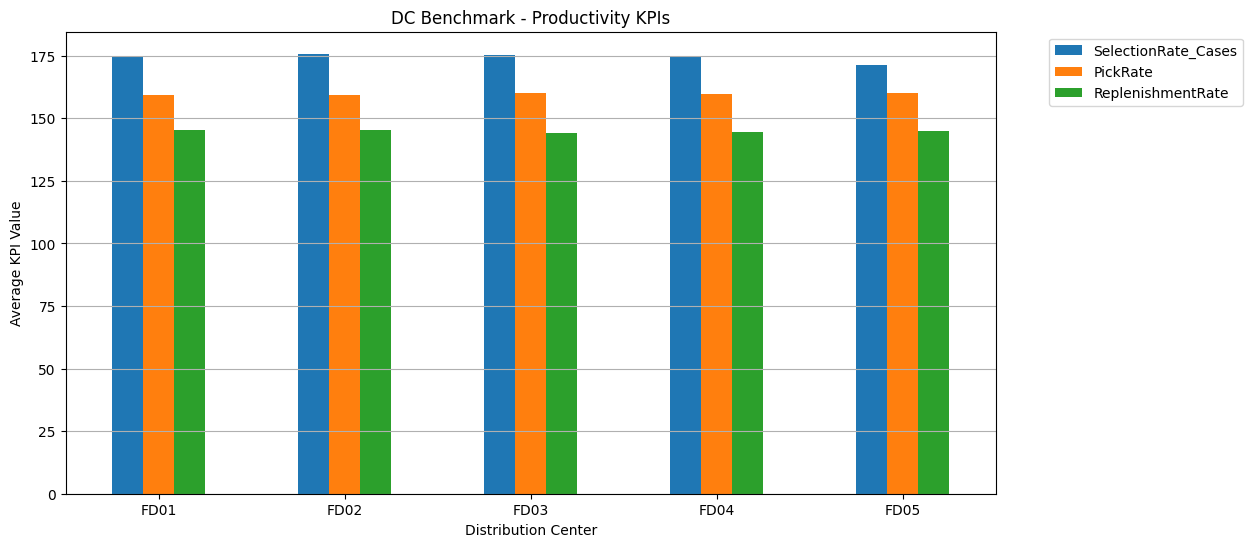

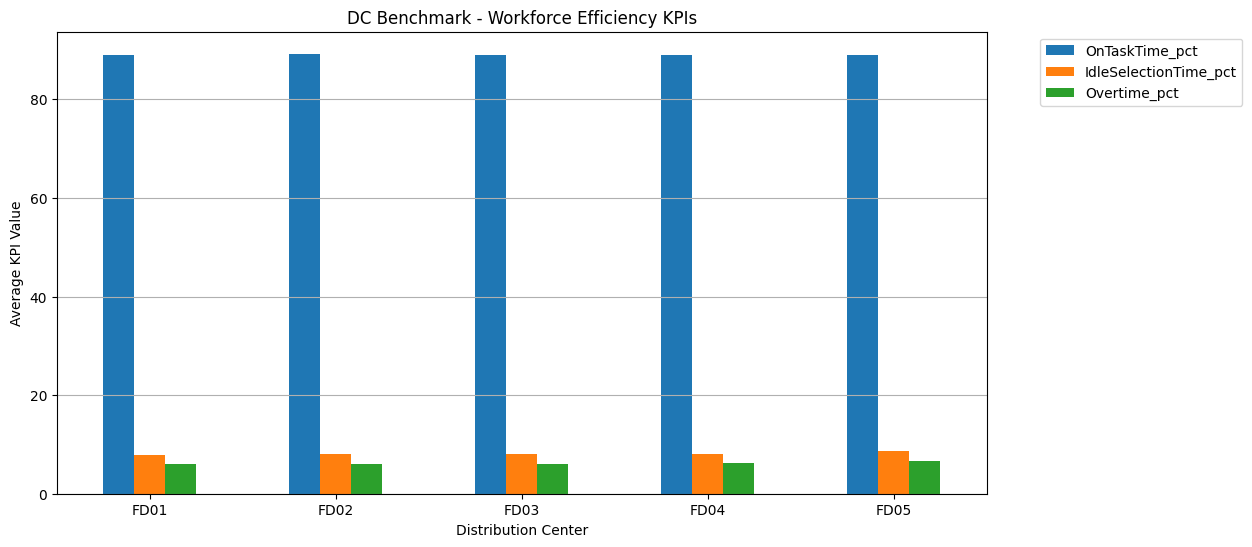

In [53]:
#Automatically creates charts for all KPI groups
    
for group_name, kpis in kpi_groups.items():

    plot_dc_benchmark(
        data=df,
        kpis=kpis,
        title=f"DC Benchmark - {group_name}"
    )

In [54]:
# Weekly Trend chart for Any KPI
def plot_weekly_trend(data, kpi):

    weekly_data = data.groupby([
        "Week",
        "Distribution_Center"
    ])[kpi].mean().reset_index()

    plt.figure(figsize=(12, 6))

    for dc in weekly_data["Distribution_Center"].unique():

        dc_data = weekly_data[
            weekly_data["Distribution_Center"] == dc
        ]

        plt.plot(
            dc_data["Week"],
            dc_data[kpi],
            marker="o",
            linewidth=2,
            label=dc
        )

    plt.title(f"Weekly Trend - {kpi}")
    plt.xlabel("Week")
    plt.ylabel(kpi)
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)

    plt.show()  


KPI: SelectionRate_Cases


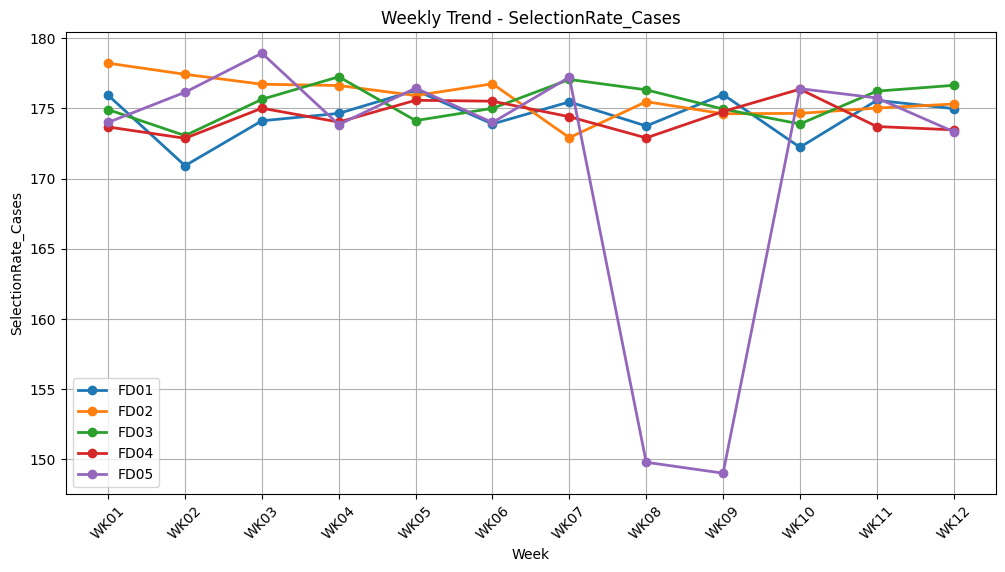


KPI: PickRate


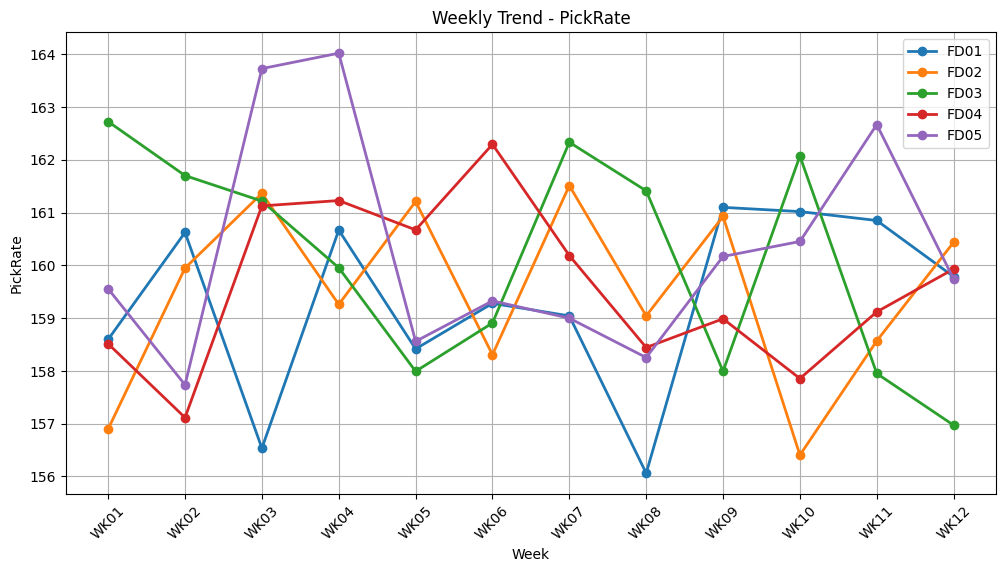


KPI: ReplenishmentRate


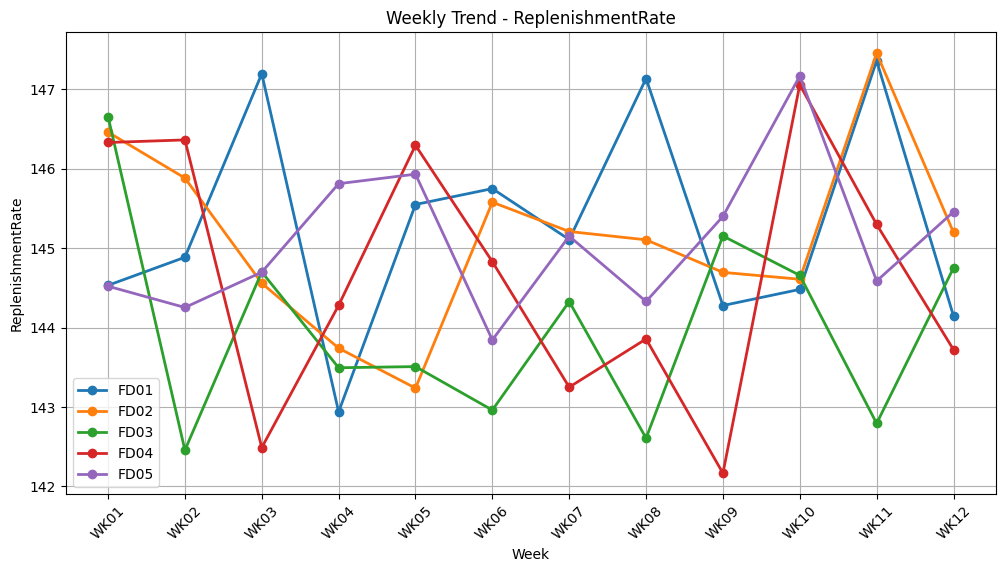


KPI: OnTaskTime_pct


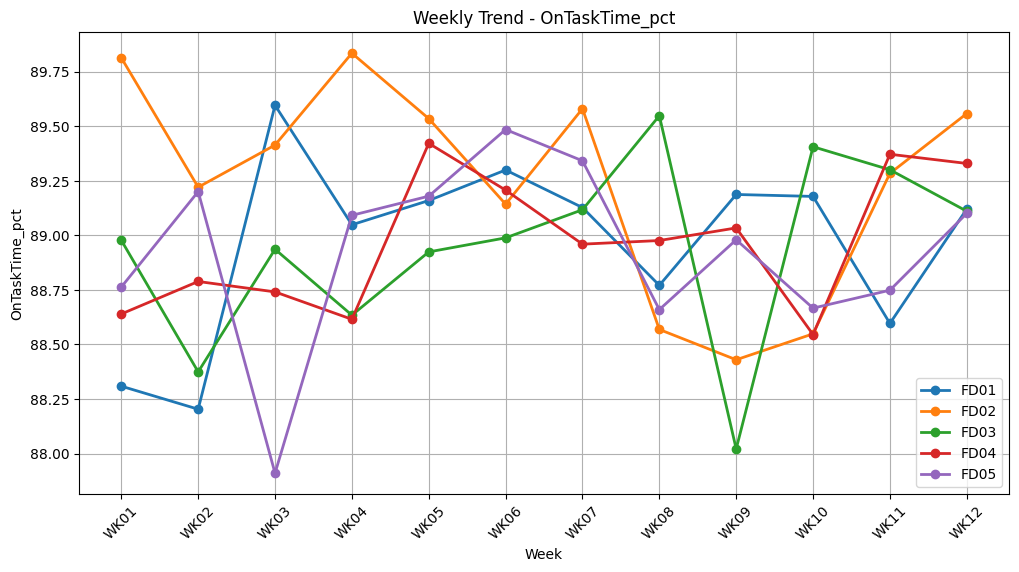


KPI: IdleSelectionTime_pct


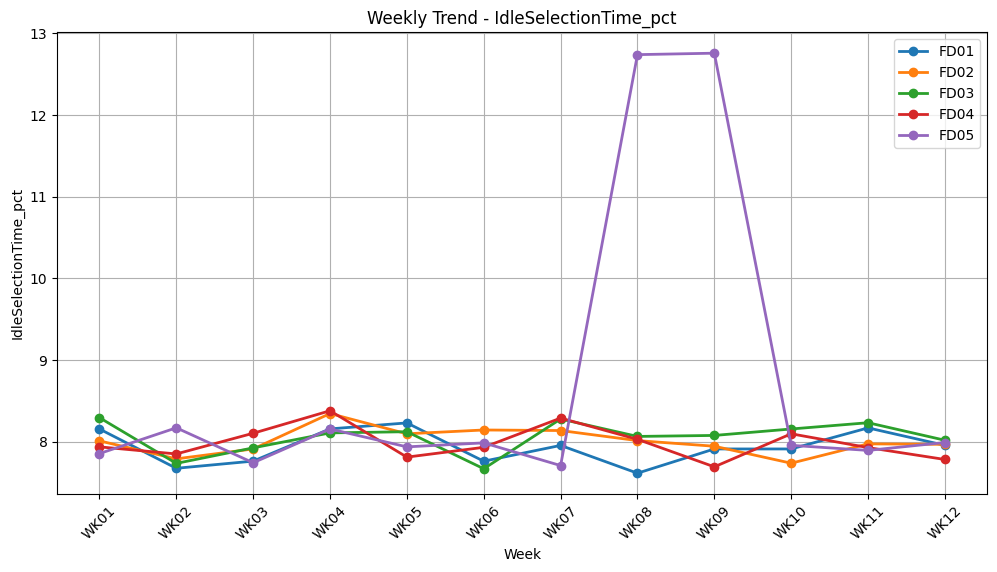


KPI: Overtime_pct


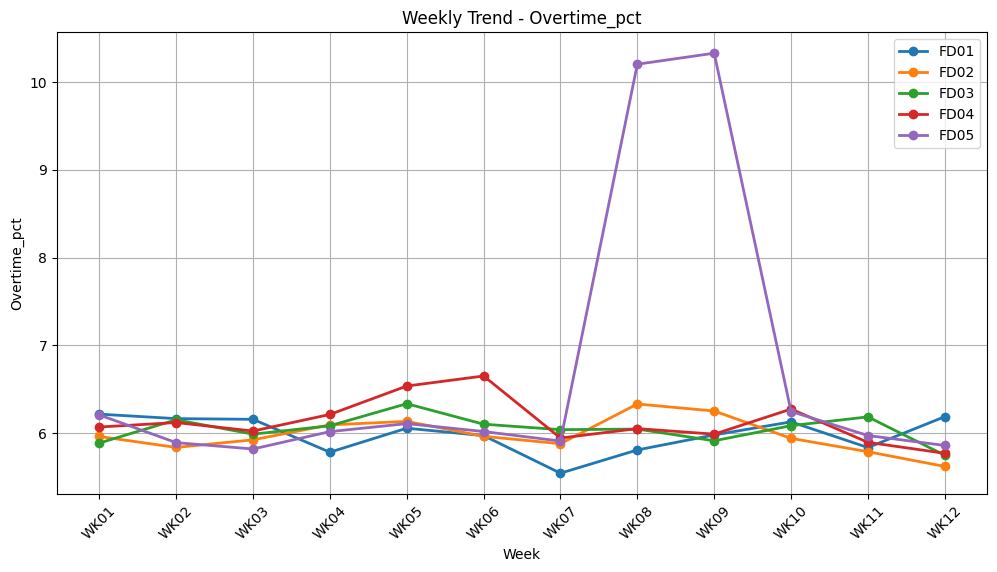

In [55]:
# View Chart + Data for All Core 

core_kpis = [
    "SelectionRate_Cases",
    "PickRate",
    "ReplenishmentRate",
    "OnTaskTime_pct",
    "IdleSelectionTime_pct",
    "Overtime_pct",
]

for kpi in core_kpis:

    print("\nKPI:", kpi)

    plot_weekly_trend(
        data=df,
        kpi=kpi
    )

In [56]:
# Target Rules

import sys

sys.path.append("../src")

from kpi_engine import kpi_rules

#print(kpi_rules)

In [57]:
# based on the rules defined above, we can create a function to evaluate performance against targets
# Creates status columns for all KPIs and Displays KPI status output

for kpi, rule in kpi_rules.items():

    target = rule["target"]
    comparison = rule["comparison"]

    status_column = kpi + "_Status"

    if comparison == "higher":

        df[status_column] = np.where(
            df[kpi] >= target,
            "Good",
            "Below Target"
        )

    elif comparison == "lower":

        df[status_column] = np.where(
            df[kpi] <= target,
            "Good",
            "Above Target"
        )

status_columns = [
    col for col in df.columns
    if col.endswith("_Status")
]

df[
    [
        "Week",
        "Distribution_Center",
        "Team",
        "Shift",
        "Employee_ID"
    ] + status_columns
].head(10)


,Week,Distribution_Center,Team,Shift,Employee_ID,SelectionRate_Cases_Status,PickRate_Status,ReplenishmentRate_Status,IdleSelectionTime_pct_Status,OnTaskTime_pct_Status,Overtime_pct_Status
0,WK01,FD01,Team A,Morning,EMP0001,Good,Below Target,Good,Above Target,Below Target,Good
1,WK01,FD01,Team A,Morning,EMP0002,Good,Below Target,Below Target,Above Target,Below Target,Good
2,WK01,FD01,Team A,Morning,EMP0003,Below Target,Below Target,Good,Good,Good,Good
3,WK01,FD01,Team A,Morning,EMP0004,Good,Below Target,Below Target,Good,Good,Good
4,WK01,FD01,Team A,Morning,EMP0005,Good,Below Target,Below Target,Above Target,Good,Above Target
5,WK01,FD01,Team A,Morning,EMP0006,Below Target,Below Target,Good,Above Target,Below Target,Above Target
6,WK01,FD01,Team A,Morning,EMP0007,Good,Good,Below Target,Good,Good,Above Target
7,WK01,FD01,Team A,Morning,EMP0008,Below Target,Good,Good,Good,Good,Above Target
8,WK01,FD01,Team A,Morning,EMP0009,Below Target,Good,Below Target,Above Target,Good,Good
9,WK01,FD01,Team A,Morning,EMP0010,Good,Good,Below Target,Good,Below Target,Above Target


In [58]:
# Detect Anomanly


from anomaly_engine import detect_anomaly

In [ ]:
########################SUMARRRIESSS

In [59]:
# lOW Permormer on EMP level
df[["Anomaly_Flag", "Anomaly_Reason"]] = df.apply(
    lambda row: pd.Series(
        detect_anomaly(
            row=row,
            kpi_rules=kpi_rules
        )
    ),
    axis=1
)
pd.set_option('display.max_colwidth', None) # To read full anomaly reason text
df[[
    "Week",
    "Distribution_Center",
    "DC_Manager",
    "Team",
    "Team_Leader",
    "Shift",
    "Employee_ID",
    "Anomaly_Flag",
    "Anomaly_Reason"
]].head(10)

,Week,Distribution_Center,DC_Manager,Team,Team_Leader,Shift,Employee_ID,Anomaly_Flag,Anomaly_Reason
0,WK01,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0001,Anomaly,PickRate below target (157.5 vs 160)\nIdleSelectionTime_pct above target (11.0 vs 8)\nOnTaskTime_pct below target (88.1 vs 89)
1,WK01,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0002,Anomaly,PickRate below target (151.7 vs 160)\nReplenishmentRate below target (139.4 vs 145)\nIdleSelectionTime_pct above target (8.5 vs 8)\nOnTaskTime_pct below target (81.3 vs 89)
2,WK01,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0003,Anomaly,SelectionRate_Cases below target (161.4 vs 175)\nPickRate below target (134.6 vs 160)
3,WK01,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0004,Anomaly,PickRate below target (149.2 vs 160)\nReplenishmentRate below target (141.5 vs 145)
4,WK01,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0005,Anomaly,PickRate below target (124.7 vs 160)\nReplenishmentRate below target (129.1 vs 145)\nIdleSelectionTime_pct above target (8.4 vs 8)\nOvertime_pct above target (6.3 vs 6)
5,WK01,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0006,Anomaly,SelectionRate_Cases below target (164.2 vs 175)\nPickRate below target (151.7 vs 160)\nIdleSelectionTime_pct above target (8.7 vs 8)\nOnTaskTime_pct below target (81.9 vs 89)\nOvertime_pct above target (6.6 vs 6)
6,WK01,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0007,Anomaly,ReplenishmentRate below target (134.9 vs 145)\nOvertime_pct above target (8.0 vs 6)
7,WK01,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0008,Anomaly,SelectionRate_Cases below target (157.1 vs 175)\nOvertime_pct above target (6.7 vs 6)
8,WK01,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0009,Anomaly,SelectionRate_Cases below target (174.5 vs 175)\nReplenishmentRate below target (113.6 vs 145)\nIdleSelectionTime_pct above target (9.6 vs 8)
9,WK01,FD01,Michael Weber,Team A,Leader_A,Morning,EMP0010,Anomaly,ReplenishmentRate below target (138.8 vs 145)\nOnTaskTime_pct below target (87.0 vs 89)\nOvertime_pct above target (7.8 vs 6)


In [60]:
#Anomaly Count by Hierarchy
# lOW Permormer on TEAM LEADER level

anomaly_by_hierarchy = df[df["Anomaly_Flag"] == "Anomaly"].groupby([
    "Distribution_Center",
    "DC_Manager",
    "Team",
    "Team_Leader",
    "Shift"
]).size().reset_index(name="Anomaly_Count")

anomaly_by_hierarchy = anomaly_by_hierarchy.sort_values(
    "Anomaly_Count",
    ascending=False
)

display(anomaly_by_hierarchy.head(20))



,Distribution_Center,DC_Manager,Team,Team_Leader,Shift,Anomaly_Count
2,FD01,Michael Weber,Team A,Leader_A,Night,120
30,FD04,Julia Becker,Team B,Leader_B,Evening,120
23,FD03,Lukas Fischer,Team B,Leader_B,Night,120
27,FD04,Julia Becker,Team A,Leader_A,Evening,120
26,FD03,Lukas Fischer,Team C,Leader_C,Night,120
37,FD05,Thomas Klein,Team A,Leader_A,Morning,120
36,FD05,Thomas Klein,Team A,Leader_A,Evening,120
18,FD03,Lukas Fischer,Team A,Leader_A,Evening,119
21,FD03,Lukas Fischer,Team B,Leader_B,Evening,119
3,FD01,Michael Weber,Team B,Leader_B,Evening,119


,Distribution_Center,Anomaly_Count
0,FD02,1054
1,FD01,1060
2,FD03,1061
3,FD04,1066
4,FD05,1068


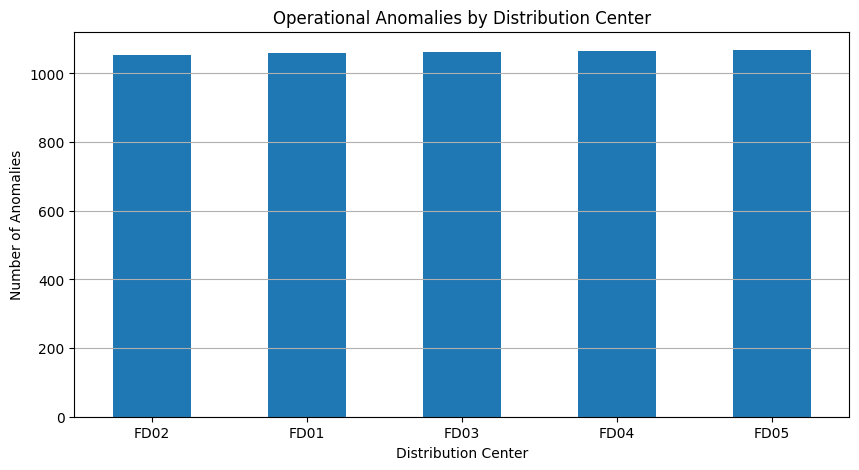

In [61]:
# lOW Permormer on DC level

anomaly_by_dc = df[df["Anomaly_Flag"] == "Anomaly"].groupby(
    "Distribution_Center"
).size().sort_values()

display(anomaly_by_dc.reset_index(name="Anomaly_Count"))

anomaly_by_dc.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Operational Anomalies by Distribution Center")
plt.xlabel("Distribution Center")
plt.ylabel("Number of Anomalies")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()
